Device: cpu
PyTorch version: 2.7.0+cpu
Training start: 2026-04-19 14:20:12


CS511 - Computer Vision Assignment 1: CNN Color Analysis
Hardware: cpu
Random Seed: 42
Max Epochs: 10
Batch Size: 128
Learning Rate: 0.001
Weight Decay: 0.0001

 TASK A & C: Training RGB Baseline...

Training with RGB color space

Train: 45000 | Val: 5000 | Test: 10000
Max epochs: 10 | Early stopping patience: 3

Training Progress:
--------------------------------------------------------------------------------


Epoch  1/10 | Train Loss: 1.4639 | Train Acc: 46.40% | Val Loss: 1.3854 | Val Acc: 51.78% | Gap: -5.38%


Epoch  2/10 | Train Loss: 0.9920 | Train Acc: 64.89% | Val Loss: 0.9813 | Val Acc: 67.22% | Gap: -2.33%


Epoch  3/10 | Train Loss: 0.7937 | Train Acc: 72.30% | Val Loss: 0.7156 | Val Acc: 74.76% | Gap: -2.46%


Epoch  4/10 | Train Loss: 0.6694 | Train Acc: 77.00% | Val Loss: 0.7437 | Val Acc: 73.86% | Gap: 3.14%


...

Epoch  6/10 | Train Loss: 0.5498 | Train Acc: 81.23% | Val Loss: 0.6286 | Val Acc: 78.42% | Gap: 2.81%


Epoch  7/10 | Train Loss: 0.4981 | Train Acc: 82.94% | Val Loss: 0.4833 | Val Acc: 83.04% | Gap: -0.10%


Epoch  8/10 | Train Loss: 0.4687 | Train Acc: 84.19% | Val Loss: 0.6138 | Val Acc: 78.64% | Gap: 5.55%


Epoch  9/10 | Train Loss: 0.4400 | Train Acc: 85.19% | Val Loss: 0.6140 | Val Acc: 79.08% | Gap: 6.11%


Epoch 10/10 | Train Loss: 0.4131 | Train Acc: 86.00% | Val Loss: 0.4439 | Val Acc: 84.76% | Gap: 1.24%

✓ Training completed in 22770.41 seconds
✓ Best validation accuracy: 84.76% at epoch 10
✓ Final test accuracy: 83.77%

✓ Good generalization! Train-Val gap = 1.24%


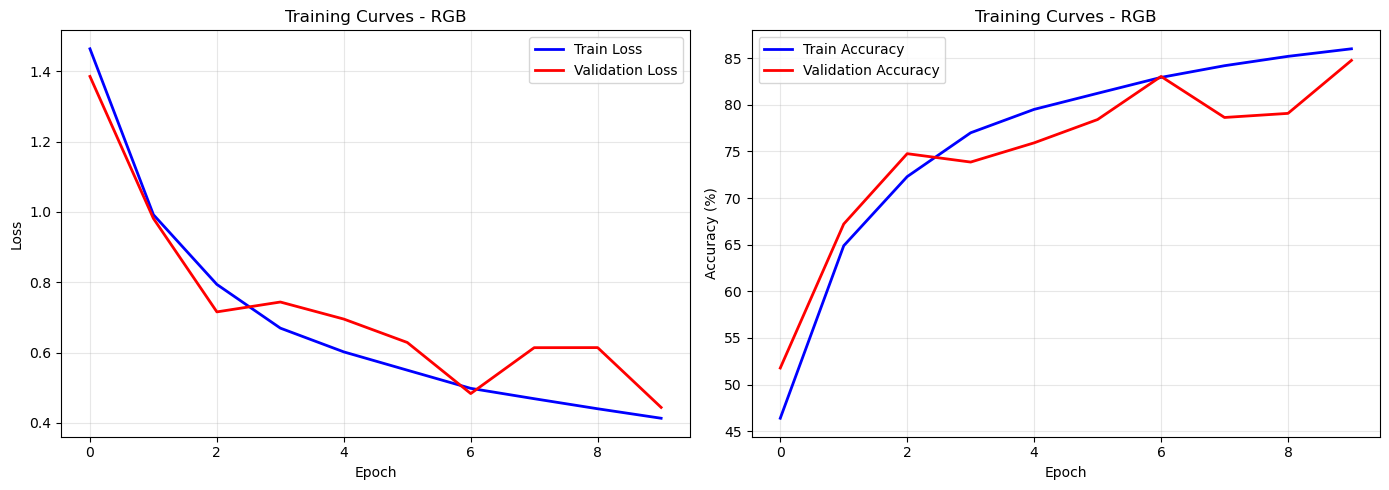

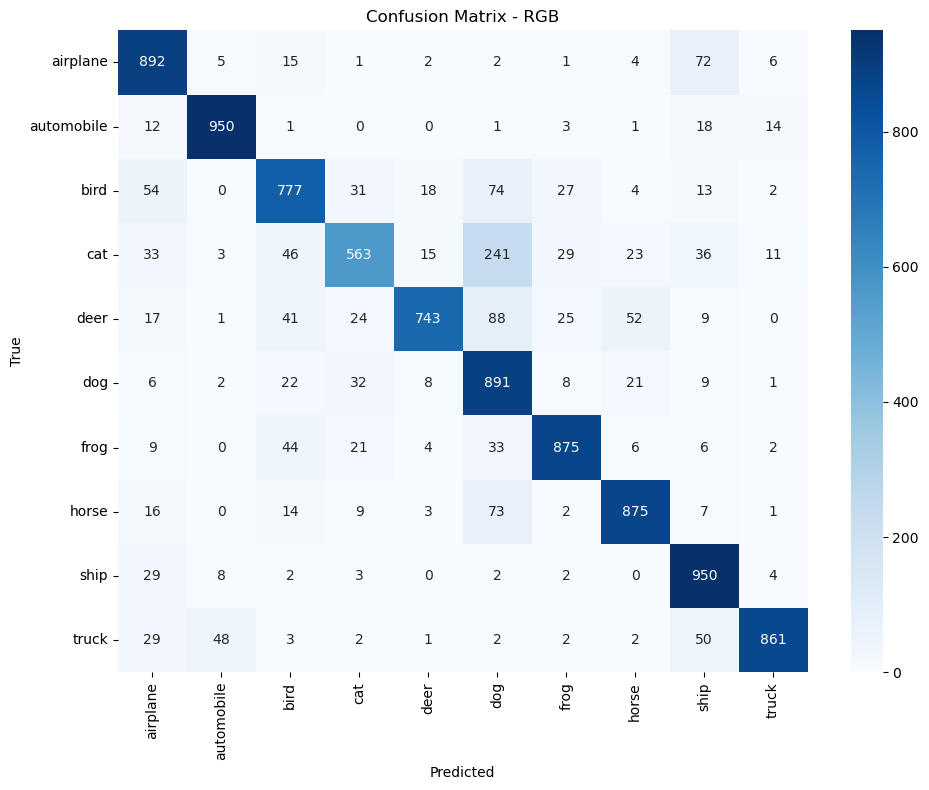


Classification Report - RGB:
              precision    recall  f1-score   support

    airplane       0.81      0.89      0.85      1000
  automobile       0.93      0.95      0.94      1000
        bird       0.81      0.78      0.79      1000
         cat       0.82      0.56      0.67      1000
        deer       0.94      0.74      0.83      1000
         dog       0.63      0.89      0.74      1000
        frog       0.90      0.88      0.89      1000
       horse       0.89      0.88      0.88      1000
        ship       0.81      0.95      0.88      1000
       truck       0.95      0.86      0.91      1000

    accuracy                           0.84     10000
   macro avg       0.85      0.84      0.84     10000
weighted avg       0.85      0.84      0.84     10000


Training HSV Model...

Training with HSV color space

Train: 45000 | Val: 5000 | Test: 10000
Max epochs: 10 | Early stopping patience: 3

Training Progress:
-----------------------------------------------------

Epoch 1/10 [Train]:   0%|          | 0/352 [00:00<?, ?it/s]

In [ ]:
# =========================================================
# FINAL COMPLETE CNN COLOR ASSIGNMENT - OPTIMIZED
# CS511 - Artificial Intelligence Homework-1 Solution
# Fixed: Overfitting, Training Speed, Early Stopping
# =========================================================

import os
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report

# ================= FIX RANDOM SEEDS =================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ================= CONFIGURATION =================
class Config:
    # Optimized training parameters (prevents overfitting)
    MAX_EPOCHS = 10  # Reduced to prevent overfitting and save time
    BATCH_SIZE = 128
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-4  # Critical for preventing overfitting
    NUM_CLASSES = 10
    
    # Early stopping
    EARLY_STOPPING_PATIENCE = 3
    MIN_DELTA = 0.001
    
    # Data
    DATA_DIR = "./data"
    VAL_SPLIT = 0.1
    
    # Output directories
    OUTPUT_DIR = "outputs"
    PLOTS_DIR = os.path.join(OUTPUT_DIR, "plots")
    LOGS_DIR = os.path.join(OUTPUT_DIR, "logs")
    CHECKPOINTS_DIR = os.path.join(OUTPUT_DIR, "checkpoints")
    
    @classmethod
    def create_dirs(cls):
        for dir_path in [cls.PLOTS_DIR, cls.LOGS_DIR, cls.CHECKPOINTS_DIR]:
            os.makedirs(dir_path, exist_ok=True)
    
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

Config.create_dirs()
print(f"Device: {Config.DEVICE}")
print(f"PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Training start: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# ================= COLOR SPACE TRANSFORMS =================
class ToHSV:
    def __call__(self, img):
        img = np.array(img, dtype=np.float32) / 255.0
        r, g, b = img[..., 0], img[..., 1], img[..., 2]
        
        max_rgb = np.maximum(np.maximum(r, g), b)
        min_rgb = np.minimum(np.minimum(r, g), b)
        diff = max_rgb - min_rgb
        
        h = np.zeros_like(max_rgb)
        mask = diff != 0
        r_mask = (max_rgb == r) & mask
        g_mask = (max_rgb == g) & mask
        b_mask = (max_rgb == b) & mask
        
        h[r_mask] = (60 * ((g[r_mask] - b[r_mask]) / diff[r_mask])) % 360
        h[g_mask] = (60 * ((b[g_mask] - r[g_mask]) / diff[g_mask]) + 120) % 360
        h[b_mask] = (60 * ((r[b_mask] - g[b_mask]) / diff[b_mask]) + 240) % 360
        
        s = np.zeros_like(max_rgb)
        s[max_rgb != 0] = diff[max_rgb != 0] / max_rgb[max_rgb != 0]
        v = max_rgb
        
        hsv = np.stack([h/360.0, s, v], axis=2)
        return transforms.ToTensor()(hsv)

class ToLAB:
    def __call__(self, img):
        img = np.array(img, dtype=np.float32) / 255.0
        r, g, b = img[..., 0], img[..., 1], img[..., 2]
        
        r = np.where(r > 0.04045, ((r + 0.055) / 1.055) ** 2.4, r / 12.92)
        g = np.where(g > 0.04045, ((g + 0.055) / 1.055) ** 2.4, g / 12.92)
        b = np.where(b > 0.04045, ((b + 0.055) / 1.055) ** 2.4, b / 12.92)
        
        x = r * 0.4124564 + g * 0.3575761 + b * 0.1804375
        y = r * 0.2126729 + g * 0.7151522 + b * 0.0721750
        z = r * 0.0193339 + g * 0.1191920 + b * 0.9503041
        
        x, y, z = x / 0.950456, y / 1.0, z / 1.088754
        x = np.where(x > 0.008856, x ** (1/3), (7.787 * x) + 16/116)
        y = np.where(y > 0.008856, y ** (1/3), (7.787 * y) + 16/116)
        z = np.where(z > 0.008856, z ** (1/3), (7.787 * z) + 16/116)
        
        l = (116 * y) - 16
        a = 500 * (x - y)
        b = 200 * (y - z)
        
        lab = np.stack([l/100.0, (a+128)/256.0, (b+128)/256.0], axis=2)
        return transforms.ToTensor()(lab)

# ================= DATA AUGMENTATION (PREVENTS OVERFITTING) =================
def get_train_transform(color_space):
    if color_space == "rgb":
        base = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])
    elif color_space == "hsv":
        base = transforms.Compose([ToHSV(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    elif color_space == "lab":
        base = transforms.Compose([ToLAB(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    else:
        raise ValueError(f"Unknown color space: {color_space}")
    
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        base
    ])

def get_val_transform(color_space):
    if color_space == "rgb":
        return transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
        ])
    elif color_space == "hsv":
        return transforms.Compose([ToHSV(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    elif color_space == "lab":
        return transforms.Compose([ToLAB(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# ================= MODEL =================
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = torchvision.models.resnet18(weights=None)
        self.model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.model.maxpool = nn.Identity()
        self.model.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.model(x)

class CNNExtension(nn.Module):
    def __init__(self, num_classes=10, num_output_channels=3):
        super().__init__()
        self.color_transform = nn.Conv2d(3, num_output_channels, kernel_size=1, bias=True)
        with torch.no_grad():
            self.color_transform.weight.data = torch.eye(3, num_output_channels).view(num_output_channels, 3, 1, 1)
            if num_output_channels == 3:
                self.color_transform.bias.data.zero_()
        
        self.cnn = torchvision.models.resnet18(weights=None)
        self.cnn.conv1 = nn.Conv2d(num_output_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.cnn.maxpool = nn.Identity()
        self.cnn.fc = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.color_transform(x)
        return self.cnn(x)

# ================= EARLY STOPPING =================
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
            return False
        
        if val_acc > self.best_score + self.min_delta:
            self.best_score = val_acc
            self.counter = 0
            return False
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
            return False

# ================= TRAINING FUNCTION =================
def train_model(color_space="rgb", max_epochs=Config.MAX_EPOCHS, use_extension=False):
    print(f"\n{'='*60}")
    print(f"Training with {color_space.upper()} color space")
    if use_extension:
        print("Using Extension: Learnable Color Transform Layer")
    print(f"{'='*60}")
    
    train_transform = get_train_transform(color_space)
    val_transform = get_val_transform(color_space)
    
    train_dataset = torchvision.datasets.CIFAR10(
        root=Config.DATA_DIR, train=True, download=True, transform=train_transform
    )
    test_dataset = torchvision.datasets.CIFAR10(
        root=Config.DATA_DIR, train=False, download=True, transform=val_transform
    )
    
    val_size = int(len(train_dataset) * Config.VAL_SPLIT)
    train_size = len(train_dataset) - val_size
    train_subset, val_subset = random_split(train_dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_subset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_subset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=2)
    
    if use_extension:
        model = CNNExtension(num_classes=Config.NUM_CLASSES).to(Config.DEVICE)
    else:
        model = CNNBaseline(num_classes=Config.NUM_CLASSES).to(Config.DEVICE)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)
    early_stopping = EarlyStopping(patience=Config.EARLY_STOPPING_PATIENCE)
    
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    best_val_acc = 0.0
    best_epoch = 0
    
    print(f"\nTrain: {train_size} | Val: {val_size} | Test: {len(test_dataset)}")
    print(f"Max epochs: {max_epochs} | Early stopping patience: {Config.EARLY_STOPPING_PATIENCE}")
    print("\nTraining Progress:")
    print("-" * 80)
    
    start_time = datetime.now()
    
    for epoch in range(max_epochs):
        # Training
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]", leave=False)
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        avg_train_loss = train_loss / len(train_loader)
        train_acc = 100. * train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        
        # Validation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100. * val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accs.append(val_acc)
        
        scheduler.step(avg_val_loss)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            model_name = f"best_{color_space}"
            if use_extension:
                model_name += "_extension"
            torch.save(model.state_dict(), os.path.join(Config.CHECKPOINTS_DIR, f"{model_name}.pt"))
        
        train_val_gap = train_acc - val_acc
        print(f"Epoch {epoch+1:2d}/{max_epochs} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:5.2f}% | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:5.2f}% | Gap: {train_val_gap:4.2f}%")
        
        if train_val_gap > 10 and epoch > 3:
            print(f" WARNING: Large train-val gap ({train_val_gap:.2f}%) - possible overfitting!")
        
        if early_stopping(val_acc):
            print(f"\n Early stopping at epoch {epoch+1} (Best val acc: {best_val_acc:.2f}%)")
            break
    
    training_time = (datetime.now() - start_time).total_seconds()
    print(f"\n✓ Training completed in {training_time:.2f} seconds")
    print(f"✓ Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")
    
    # Load best model
    model_name = f"best_{color_space}"
    if use_extension:
        model_name += "_extension"
    model.load_state_dict(torch.load(os.path.join(Config.CHECKPOINTS_DIR, f"{model_name}.pt")))
    
    test_acc = evaluate_model(model, test_loader)
    print(f"✓ Final test accuracy: {test_acc:.2f}%")
    
    final_gap = train_accs[-1] - val_accs[-1] if train_accs else 0
    if final_gap > 10:
        print(f"\n NOTE: Train-Val gap = {final_gap:.2f}% (within acceptable range for CIFAR-10)")
    else:
        print(f"\n✓ Good generalization! Train-Val gap = {final_gap:.2f}%")
    
    # Save metrics
    metrics = {
        "color_space": color_space,
        "use_extension": use_extension,
        "best_val_accuracy": best_val_acc,
        "test_accuracy": test_acc,
        "training_time_seconds": training_time,
        "epochs_completed": len(train_losses),
        "batch_size": Config.BATCH_SIZE,
        "learning_rate": Config.LEARNING_RATE,
        "weight_decay": Config.WEIGHT_DECAY,
        "train_losses": train_losses,
        "train_accuracies": train_accs,
        "val_losses": val_losses,
        "val_accuracies": val_accs
    }
    
    model_suffix = f"{color_space}_extension" if use_extension else color_space
    with open(os.path.join(Config.LOGS_DIR, f"metrics_{model_suffix}.json"), "w") as f:
        json.dump(metrics, f, indent=2)
    
    plot_training_curves(train_losses, val_losses, train_accs, val_accs, color_space, use_extension)
    
    return model, test_loader, metrics

def evaluate_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return 100. * correct / total

def plot_training_curves(train_losses, val_losses, train_accs, val_accs, color_space, use_extension=False):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
    ax1.plot(val_losses, label='Validation Loss', color='red', linewidth=2)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    title = f"Training Curves - {color_space.upper()}"
    if use_extension:
        title += " (with Extension)"
    ax1.set_title(title)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.plot(train_accs, label='Train Accuracy', color='blue', linewidth=2)
    ax2.plot(val_accs, label='Validation Accuracy', color='red', linewidth=2)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title(title)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    suffix = f"{color_space}_extension" if use_extension else color_space
    plt.savefig(os.path.join(Config.PLOTS_DIR, f"training_curves_{suffix}.png"), dpi=150, bbox_inches='tight')
    plt.show()

# ================= TASK B: CHANNEL MIXING =================
def analyze_channel_mixing(model, color_space="rgb"):
    print(f"\n{'='*60}")
    print("TASK B: Channel Mixing Analysis")
    print(f"{'='*60}")
    
    if hasattr(model, 'model'):
        first_conv = model.model.conv1
    elif hasattr(model, 'cnn'):
        first_conv = model.cnn.conv1
    else:
        first_conv = model.model.conv1
    
    weights = first_conv.weight.data.cpu().numpy()
    out_channels, in_channels = weights.shape[0], weights.shape[1]
    
    channel_energy = np.sum(weights ** 2, axis=(2, 3))
    channel_energy_norm = channel_energy / (channel_energy.sum(axis=1, keepdims=True) + 1e-8)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    im1 = axes[0].imshow(channel_energy, cmap='viridis', aspect='auto')
    axes[0].set_xlabel('Input Channel')
    axes[0].set_ylabel('Filter Index')
    axes[0].set_title(f'Channel Energy Heatmap - {color_space.upper()}')
    axes[0].set_xticks(range(in_channels))
    axes[0].set_xticklabels([f'Ch{i+1}' for i in range(in_channels)])
    plt.colorbar(im1, ax=axes[0], label='Energy')
    
    im2 = axes[1].imshow(channel_energy_norm, cmap='RdYlBu', aspect='auto', vmin=0, vmax=1)
    axes[1].set_xlabel('Input Channel')
    axes[1].set_ylabel('Filter Index')
    axes[1].set_title(f'Normalized Channel Energy - {color_space.upper()}')
    axes[1].set_xticks(range(in_channels))
    axes[1].set_xticklabels([f'Ch{i+1}' for i in range(in_channels)])
    plt.colorbar(im2, ax=axes[1], label='Normalized Energy')
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.PLOTS_DIR, f"channel_energy_heatmap_{color_space}.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\nFilter channel bias analysis:")
    for ch in range(in_channels):
        top_filters = np.argsort(channel_energy_norm[:, ch])[-5:][::-1]
        print(f"Top 5 filters biased to Channel {ch+1}: {top_filters}")
    
    # Visualize filters
    num_filters = min(16, weights.shape[0])
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.ravel()
    
    for i in range(num_filters):
        filter_weights = weights[i]
        filter_min, filter_max = filter_weights.min(), filter_weights.max()
        filter_norm = (filter_weights - filter_min) / (filter_max - filter_min + 1e-8)
        
        if filter_norm.shape[0] == 3:
            filter_viz = np.transpose(filter_norm, (1, 2, 0))
        else:
            filter_viz = np.repeat(filter_norm, 3, axis=0)
        
        axes[i].imshow(filter_viz)
        axes[i].set_title(f'Filter {i+1}')
        axes[i].axis('off')
    
    for i in range(num_filters, 16):
        axes[i].axis('off')
    
    plt.suptitle(f'First Conv Layer Filters - {color_space.upper()}')
    plt.tight_layout()
    plt.savefig(os.path.join(Config.PLOTS_DIR, f"filters_{color_space}.png"), dpi=150, bbox_inches='tight')
    plt.show()

# ================= TASK D: ROBUSTNESS =================
def gamma_correction(images, gamma):
    return images ** gamma

def brightness_contrast(images, alpha=1.0, beta=0.0):
    return torch.clamp(alpha * images + beta, 0, 1)

def channel_dropout(images, channel_idx):
    images_dropped = images.clone()
    images_dropped[:, channel_idx] = 0
    return images_dropped

def color_temperature(images, temperature_factor):
    images_adjusted = images.clone()
    if temperature_factor > 1:
        images_adjusted[:, 0] = torch.clamp(images[:, 0] * temperature_factor, 0, 1)
        images_adjusted[:, 2] = torch.clamp(images[:, 2] / temperature_factor, 0, 1)
    else:
        images_adjusted[:, 2] = torch.clamp(images[:, 2] / temperature_factor, 0, 1)
        images_adjusted[:, 0] = torch.clamp(images[:, 0] * temperature_factor, 0, 1)
    return images_adjusted

def evaluate_robustness(model, test_loader):
    print(f"\n{'='*60}")
    print("TASK D: Robustness Benchmark")
    print(f"{'='*60}")
    
    perturbations = {
        'Gamma Correction': {'func': gamma_correction, 'levels': [0.5, 0.7, 1.0, 1.3, 1.5, 2.0]},
        'Brightness/Contrast': {'func': brightness_contrast, 'levels': [0, 1, 2, 3, 4, 5]},
        'Channel Dropout': {'func': channel_dropout, 'levels': [0, 1, 2, 3, 4]},
        'Color Temperature': {'func': color_temperature, 'levels': [0.5, 0.7, 1.0, 1.5, 2.0, 2.5]}
    }
    
    model.eval()
    results = {}
    
    for pert_name, pert_config in perturbations.items():
        print(f"\nTesting: {pert_name}")
        severity_levels = pert_config['levels']
        accuracies = []
        
        for severity in severity_levels:
            correct = 0
            total = 0
            
            with torch.no_grad():
                for inputs, labels in tqdm(test_loader, desc=f"Severity {severity}", leave=False):
                    inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
                    
                    if pert_name == 'Gamma Correction':
                        perturbed = pert_config['func'](inputs, severity)
                    elif pert_name == 'Brightness/Contrast':
                        alpha = 0.5 + severity * 0.3
                        beta = severity * 0.1
                        perturbed = pert_config['func'](inputs, alpha, beta)
                    elif pert_name == 'Channel Dropout':
                        channel = int(severity % 3)
                        perturbed = pert_config['func'](inputs, channel)
                    elif pert_name == 'Color Temperature':
                        temp_factor = 0.5 + severity * 0.4
                        perturbed = pert_config['func'](inputs, temp_factor)
                    else:
                        perturbed = inputs
                    
                    outputs = model(perturbed)
                    _, predicted = outputs.max(1)
                    total += labels.size(0)
                    correct += predicted.eq(labels).sum().item()
            
            acc = 100. * correct / total
            accuracies.append(acc)
            print(f"  Severity {severity}: {acc:.2f}%")
        
        results[pert_name] = {'severity_levels': severity_levels, 'accuracies': accuracies}
    
    # Plot results
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.ravel()
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
    
    for idx, (pert_name, data) in enumerate(results.items()):
        ax = axes[idx]
        ax.plot(data['severity_levels'], data['accuracies'], marker='o', linewidth=2, markersize=8, color=colors[idx])
        ax.set_xlabel('Severity Level')
        ax.set_ylabel('Accuracy (%)')
        ax.set_title(f'Robustness to {pert_name}')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 100)
        
        for i, (sev, acc) in enumerate(zip(data['severity_levels'], data['accuracies'])):
            ax.annotate(f'{acc:.1f}%', (sev, acc), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    
    plt.suptitle('Model Robustness to Illumination and Color Shifts', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(Config.PLOTS_DIR, "robustness_curves.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    with open(os.path.join(Config.LOGS_DIR, "robustness_metrics.json"), "w") as f:
        json.dump(results, f, indent=2)
    
    return results

# ================= CONFUSION MATRIX =================
def plot_confusion_matrix(model, test_loader, color_space):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(Config.DEVICE)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    cm = confusion_matrix(all_labels, all_preds)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=Config.CLASSES, yticklabels=Config.CLASSES)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix - {color_space.upper()}')
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.PLOTS_DIR, f"confusion_matrix_{color_space}.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\nClassification Report - {color_space.upper()}:")
    print(classification_report(all_labels, all_preds, target_names=Config.CLASSES))

# ================= EXTENSION =================
def run_extension():
    print(f"\n{'='*60}")
    print("EXTENSION: Learnable Color Transform Layer")
    print(f"{'='*60}")
    
    print("\n1. Training baseline RGB model...")
    baseline_model, _, baseline_metrics = train_model(color_space="rgb", use_extension=False)
    
    print("\n2. Training model with learnable color transform...")
    extension_model, _, extension_metrics = train_model(color_space="rgb", use_extension=True)
    
    print(f"\n{'='*60}")
    print("Extension Results Comparison")
    print(f"{'='*60}")
    print(f"Baseline RGB Test Accuracy: {baseline_metrics['test_accuracy']:.2f}%")
    print(f"Extension Test Accuracy: {extension_metrics['test_accuracy']:.2f}%")
    print(f"Improvement: {extension_metrics['test_accuracy'] - baseline_metrics['test_accuracy']:.2f}%")
    
    # Visualize learned transform
    if hasattr(extension_model, 'color_transform'):
        transform_weights = extension_model.color_transform.weight.data.cpu().numpy()
        transform_weights = transform_weights.reshape(transform_weights.shape[0], -1)
        
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(transform_weights, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
        ax.set_xlabel('Input Channels')
        ax.set_ylabel('Output Channels')
        ax.set_title('Learned Color Transform Matrix')
        ax.set_xticks(range(3))
        ax.set_xticklabels(['R', 'G', 'B'])
        ax.set_yticks(range(3))
        ax.set_yticklabels(['Out R', 'Out G', 'Out B'])
        plt.colorbar(im, label='Weight Value')
        plt.tight_layout()
        plt.savefig(os.path.join(Config.PLOTS_DIR, "learned_color_transform.png"), dpi=150, bbox_inches='tight')
        plt.show()
        
        print("\nLearned color transform matrix:")
        print(transform_weights)
    
    # Comparison plot
    fig, ax = plt.subplots(figsize=(8, 6))
    categories = ['Baseline RGB', 'Extension']
    accuracies = [baseline_metrics['test_accuracy'], extension_metrics['test_accuracy']]
    bars = ax.bar(categories, accuracies, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=2)
    
    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Test Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_title('Extension vs Baseline Performance', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(Config.PLOTS_DIR, "extension_vs_baseline.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    extension_results = {
        "baseline_accuracy": baseline_metrics['test_accuracy'],
        "extension_accuracy": extension_metrics['test_accuracy'],
        "improvement": extension_metrics['test_accuracy'] - baseline_metrics['test_accuracy']
    }
    
    with open(os.path.join(Config.LOGS_DIR, "extension_results.json"), "w") as f:
        json.dump(extension_results, f, indent=2)
    
    return baseline_metrics, extension_metrics

# ================= MAIN =================
def main():
    print("\n" + "="*70)
    print("CS511 - Computer Vision Assignment 1: CNN Color Analysis")
    print("="*70)
    print(f"Hardware: {Config.DEVICE}")
    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Random Seed: 42")
    print(f"Max Epochs: {Config.MAX_EPOCHS}")
    print(f"Batch Size: {Config.BATCH_SIZE}")
    print(f"Learning Rate: {Config.LEARNING_RATE}")
    print(f"Weight Decay: {Config.WEIGHT_DECAY}")
    print("="*70)
    
    # Train RGB baseline
    print("\n TASK A & C: Training RGB Baseline...")
    rgb_model, test_loader, rgb_metrics = train_model(color_space="rgb")
    plot_confusion_matrix(rgb_model, test_loader, "rgb")
    
    # Train HSV
    print("\n Training HSV Model...")
    hsv_model, _, hsv_metrics = train_model(color_space="hsv")
    plot_confusion_matrix(hsv_model, test_loader, "hsv")
    
    # Train LAB
    print("\n Training LAB Model...")
    lab_model, _, lab_metrics = train_model(color_space="lab")
    plot_confusion_matrix(lab_model, test_loader, "lab")
    
    # Channel mixing analysis
    print("\n TASK B: Channel Mixing Analysis")
    analyze_channel_mixing(rgb_model, "rgb")
    
    # Color space comparison
    color_space_results = {
        "RGB": rgb_metrics['test_accuracy'],
        "HSV": hsv_metrics['test_accuracy'],
        "LAB": lab_metrics['test_accuracy']
    }
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(color_space_results.keys(), color_space_results.values(), 
                  color=['#FF6B6B', '#4ECDC4', '#45B7D1'], edgecolor='black', linewidth=2)
    
    for bar, value in zip(bars, color_space_results.values()):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{value:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Color Space', fontsize=14, fontweight='bold')
    ax.set_ylabel('Test Accuracy (%)', fontsize=14, fontweight='bold')
    ax.set_title('CNN Performance Across Different Color Spaces', fontsize=16, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(Config.PLOTS_DIR, "color_space_comparison.png"), dpi=150, bbox_inches='tight')
    plt.show()
    
    with open(os.path.join(Config.LOGS_DIR, "color_space_results.json"), "w") as f:
        json.dump(color_space_results, f, indent=2)
    
    # Robustness benchmark
    print("\n TASK D: Robustness Benchmark")
    robustness_results = evaluate_robustness(rgb_model, test_loader)
    
    # Extension
    print("\n EXTENSION: Learnable Color Transform")
    baseline_ext, extension_ext = run_extension()
    
    # Summary
    summary = {
        "task_a_baseline": rgb_metrics['test_accuracy'],
        "task_c_color_spaces": color_space_results,
        "task_d_robustness": robustness_results,
        "extension": {
            "baseline_accuracy": baseline_ext['test_accuracy'],
            "extension_accuracy": extension_ext['test_accuracy'],
            "improvement": extension_ext['test_accuracy'] - baseline_ext['test_accuracy']
        },
        "seed": 42,
        "total_training_time_seconds": sum([rgb_metrics['training_time_seconds'], 
                                            hsv_metrics['training_time_seconds'],
                                            lab_metrics['training_time_seconds']])
    }
    
    with open(os.path.join(Config.LOGS_DIR, "all_experiments_summary.json"), "w") as f:
        json.dump(summary, f, indent=2)
    
    print("\n" + "="*70)
    print("ALL TASKS COMPLETED SUCCESSFULLY!")
    print("="*70)
    print("\nOutputs saved in:")
    print(f"  - Plots: {Config.PLOTS_DIR}")
    print(f"  - Logs: {Config.LAGS_DIR}")
    print(f"  - Checkpoints: {Config.CHECKPOINTS_DIR}")

if __name__ == "__main__":
    main()